## 

## Lang Graph 
### Graph
- LangGraph의 그래프는 구글의 프리겔에서 영감을 받은 슈퍼스텝방식으로 동작한다. 
- 슈퍼스텝은 그래프의 처리 과정의 한 단계로 각 노드가 병렬로 동시에 작업을 수행하는 단위이다.
- 동시에 실행되는 노드는 슈퍼스텝에 속하며 순차적으로 실행되는 노드는 별도의 슈퍼스텝에 속한다.
- 노드는 하나 이상의 입력 엣지에서 새로운 메시지를 수신할 때 활성화 된다. 활성화된 노드는 자신의 기능을 실행하고 처리 결과를 다른 노드로 전달한다. 
- 각 슈퍼스텝이 끝날 때 입력 메시지가 없는 노드는 비활성화로 표시하여 완료된 상태로 표시한다. 
- 모든 노드가 비활성화 되면 더 이상 메시지가 전송되지 않은 상태가 되면 그래프 실행이 종료된다.
  
### State
- 그래프를 정의할 때 가장 먼저 선행되어야 하는 것은 그래프의 상태를 정의하는 것이다. 
- 상태란 애플리케이션 내에서 메시지로 주고 받는 변수들의 집합이다. 
- 상태는 그래프 내 모든 노드와 엣지의 입력으로 사용되며 각 노드는 상태를 업데이트 할 수 있다. 

### Node 
- 그래프에서 노드는 실제 작업을 수행하는 실행 단위다. 
- 에이전트의 로직을 담은 파이썬 함수가 곧 노드가 되며 그래프에서 노드는 상태를 입력으로 받아 동작하고 그 결과로 상태값을 업데이트 하여 반환한다. 
- 노드는 첫번째 인자로 상태값을 두번째 인자로 설정값을 받는다. 

In [3]:
from typing import TypedDict, Annotated 
from operator import add 

class State(TypedDict):
    count: int 
    messages: Annotated[list[str], add] 
    
state = State({
    "count": 1,
    "messages": ["hello"]
})


state["messages"].append("world")
print(state)


{'count': 1, 'messages': ['hello', 'world']}


In [8]:
from langchain_core.runnables import RunnableConfig 
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages 

# 상태 그래프 선언 
builder = StateGraph(dict)

# 노드로 사용할 함수 정의 
def my_node(state: dict, config: RunnableConfig):
    print("In node", config["configurable"]["user_id"])
    return {"results" : f"Hello {state['input']}!"}


def my_other_node(state: dict):
    return state

builder.add_node("my_node", my_node) 
builder.add_node("other_node", my_other_node)


In [9]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [ ]:
from langchain_openai import ChatOpenAI 

llm = ChatOpenAI(
        model="gemma-3-4b-it",
        base_url="http://localhost:1234/v1",
        api_key="lm-studio",
        temperature=0.2
        )


def chatbot(state: State):
    return {"messages" : [llm.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

In [12]:
while True:
    user_input = input("User : ")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Good bye!")
        break 
    
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant ", value["messages"][-1].content)

Assistant  저는 **Gemma 4**입니다.

Google DeepMind에서 개발한 대규모 언어 모델(Large Language Model)이며, 사용자님의 질문에 답하고 도움을 드리기 위해 존재하는 AI입니다.
Assistant  저도 반가워요! 😊

어떤 이야기를 하고 싶으신가요? 편하게 말씀해주세요.
Good bye!


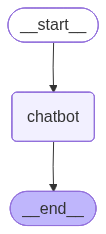

In [13]:
from IPython.display import Image, display 
display(Image(graph.get_graph().draw_mermaid_png()))


#### SearxSearchWrapper 

In [22]:
from langchain_community.utilities import SearxSearchWrapper 
from langchain_core.tools import Tool
import time 

search = SearxSearchWrapper(
    searx_host="http://localhost:8080"
)

tool = Tool(
    name="search",
    description="Search the web",
    func=search.run
)

tools = [tool] 
start = time.perf_counter()
print(tool.invoke("2026년 7월 10일 서울 날씨는?"))
end = time.perf_counter()
print(f"실행 시간: {end - start:.4f}초")

2026-07-10, 2026-07-11, 2026-07-12. Description, Cloudy With ... Seoul, Republic of Korea © 2026 Seoul Tourism Organization. All rights ...

7/8. 81° · 91%. Brief morning showers, cloudy, very humid and not as warm with a strong thunderstorm in the area this afternoon ; 7/9. 79° · 79%. Cloudy and humid; ...

2026년 7월 6일 기준 실시간 날씨 예측 마켓을 탐색하세요. 세계 최대 예측 마켓™에서 실시간 확률을 추적하고 거래하세요.

Apr 8, 2026 ... 전국 날씨 — 2026.06.07.(일) 7시 기준 #날씨 #일기예보 #전국날씨 ... Photo by Seong Jae Hong on June 10, 2026. May be a graphic of.

May 19, 2026 ... 6월 말인데 선선한 이유? 올해 장마 7월 시작 ☔️ 6월 말인데도 선선한 기온과 낮은 습도로 쾌적한 날씨가 이어지고 있습니다. 서울의 아침 기온은 19.2 ...

Within reach of everyone's unique tastes, 29CM offers inspiration and hints to perfect your style. □ 29CM: In-Depth Curation for Discovering Your Tastes ...

대한민국 국가대표팀과 함께 현지에서 활동할 스탭을 모집합니다. □ 모집 분야 * 통역 1명 * 미디어팀 1명 (사진·영상 촬영) □ 활동 기간 * 2026년 9월 21일 ~ 9 ...

Mar 26, 2026 ... 10월 13일, 미8군 군악대의 스파르탄 브래스 밴드가 광주 충장 축제 ... 이번 뮤직비디오는 다가오는 7월 27일 정전 협정날을 기념하여 미국과 ...

❌ 10.07.2026

#### DuckDuckgo

In [23]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()
start = time.perf_counter()
print(search.invoke("오늘 서울 날씨는?"))
end = time.perf_counter()
print(f"실행 시간: {end - start:.4f}초")

May 7, 2026 - 안팎 * 예상 강수량(10일)- (수도권) 서해5도: 20~60mm/ 서울.인천.경기: 5~40mm- (강원도) 강원내륙.산지: 5~40mm ... 11시 발표 : 오늘의 최저기온은 03시~09시 사이에 관측된 아침 최저기온이며, ... March 12, 2026 - Current Seoul weather condition is Sunny with real-time temperature (11°C), humidity 47%, wind 6.5km/h, pressure (1028mb), UV (3.4), visibility (9km) in Seoul. 현재위치 우선: PC브라우저의 위치정보나 스마트폰의 GPS정보로 현위치를 확인하여 표출합니다. 관심지역 우선: 관심지역으로 추가된 지점을 우선 표출합니다. 위치 미확인: 브라우저에서 위치확인을 요청하지 않습니다. 조회한 지역이 없을 경우 기상청 서울청사 위치를 보여줍니다. 4 days ago - 절기 '하지'인 오늘, 다시 더워집니다. 서울 낮 기온 29도로 어제보다 ... 202606210736046531 · 2026.06.21 07:36 · 공유하기 · 공유하기 닫기 · 페이스북 · 트위터 · 밴드 · 카카오톡 · 복사하기 ... April 15, 2026 - [보도자료] 수도권기상청-서울시, 극한기상 대응 협력 강화를 위한 기상기후 정책대응협의회 개최 2026/04/07
실행 시간: 2.8636초
